In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def create_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
model_fixed = create_model()

model_fixed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

loss_fixed, acc_fixed = model_fixed.evaluate(x_test, y_test, verbose=0)

print("Fixed Learning Rate Test Accuracy :", acc_fixed)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8873 - loss: 0.3601 - val_accuracy: 0.9554 - val_loss: 0.1427
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9637 - loss: 0.1218 - val_accuracy: 0.9587 - val_loss: 0.1391
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9704 - loss: 0.0982 - val_accuracy: 0.9710 - val_loss: 0.1098
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9773 - loss: 0.0765 - val_accuracy: 0.9658 - val_loss: 0.1319
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9755 - loss: 0.0794 - val_accuracy: 0.9709 - val_loss: 0.1081
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9802 - loss: 0.0646 - val_accuracy: 0.9695 - val_loss: 0.1179
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9817 - loss: 0.0618 - val_accuracy: 0.9656 - val_loss: 0.1434
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9833 - loss: 0.0577 - val_accuracy: 0.

In [ ]:
def lr_schedule(epoch, lr):
    if epoch < 5:
        return 0.01
    else:
        return 0.001

In [ ]:
model_sched = create_model()

model_sched.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_callback = LearningRateScheduler(lr_schedule)

history_sched = model_sched.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    callbacks=[lr_callback],
    verbose=1
)

loss_sched, acc_sched = model_sched.evaluate(x_test, y_test, verbose=0)

print("Learning Rate Scheduling Test Accuracy :", acc_sched)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8716 - loss: 0.3934 - val_accuracy: 0.9573 - val_loss: 0.1366 - learning_rate: 0.0100
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9634 - loss: 0.1215 - val_accuracy: 0.9646 - val_loss: 0.1335 - learning_rate: 0.0100
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9696 - loss: 0.1003 - val_accuracy: 0.9682 - val_loss: 0.1091 - learning_rate: 0.0100
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9757 - loss: 0.0804 - val_accuracy: 0.9646 - val_loss: 0.1213 - learning_rate: 0.0100
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9762 - loss: 0.0782 - val_accuracy: 0.9654 - val_loss: 0.1511 - learning_rate: 0.0100
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9871 - loss: 0.0434 - val_accuracy: 0.9780 - val_loss: 0.0841 - learning_rate: 0.0010
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9934 - loss: 0.0219 - 

In [ ]:
model_early = create_model()

model_early.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_early = model_early.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

loss_early, acc_early = model_early.evaluate(x_test, y_test, verbose=0)

print("Early Stopping Test Accuracy :", acc_early)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8267 - loss: 0.6074 - val_accuracy: 0.9545 - val_loss: 0.1515
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9578 - loss: 0.1419 - val_accuracy: 0.9634 - val_loss: 0.1219
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9718 - loss: 0.0955 - val_accuracy: 0.9709 - val_loss: 0.0922
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9779 - loss: 0.0706 - val_accuracy: 0.9735 - val_loss: 0.0866
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9832 - loss: 0.0552 - val_accuracy: 0.9739 - val_loss: 0.0813
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9873 - loss: 0.0433 - val_accuracy: 0.9736 - val_loss: 0.0862
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9880 - loss: 0.0376 - val_accuracy: 0.9770 - val_loss: 0.0769
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9917 - loss: 0.0291 - val_accuracy: 0.

In [ ]:
import pandas as pd

table = pd.DataFrame({
    "Method": [
        "Fixed Learning Rate",
        "Learning Rate Scheduling",
        "Early Stopping"
    ],
    "Test Accuracy": [
        acc_fixed,
        acc_sched,
        acc_early
    ]
})

table

,Method,Test Accuracy
0,Fixed Learning Rate,0.9723
1,Learning Rate Scheduling,0.9791
2,Early Stopping,0.9789


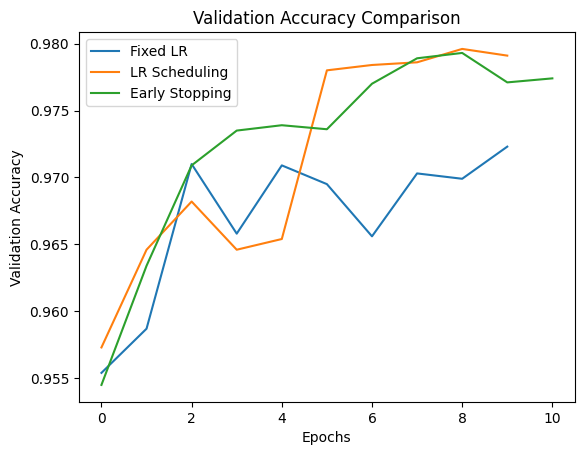

In [ ]:
plt.plot(history_fixed.history['val_accuracy'], label='Fixed LR')
plt.plot(history_sched.history['val_accuracy'], label='LR Scheduling')
plt.plot(history_early.history['val_accuracy'], label='Early Stopping')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

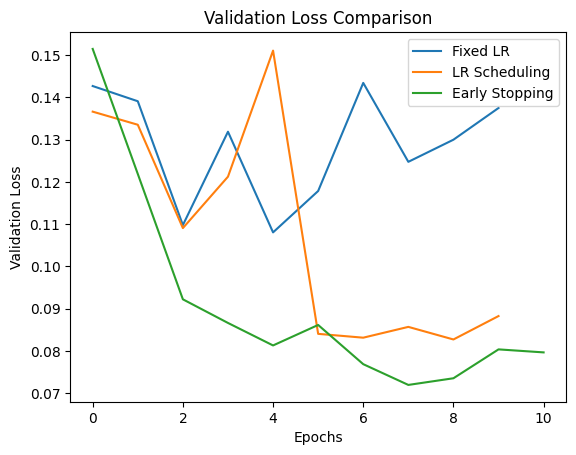

In [ ]:
plt.plot(history_fixed.history['val_loss'], label='Fixed LR')
plt.plot(history_sched.history['val_loss'], label='LR Scheduling')
plt.plot(history_early.history['val_loss'], label='Early Stopping')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()